## <span style='font-weight:bold;color:#D13CC8'>Aim of this Notebook 📓 </span>
### Discussing the algorithm of Expectation-Minimization Clustering and the K-mean Clustering.

## <span style='font-weight:bold;color:#D13CC8'>Importing Libraries</span>

In [7]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from math import sqrt, pi
from matplotlib.widgets import Slider, Button
from numpy.core.shape_base import block
from scipy.spatial import Voronoi, voronoi_plot_2d
import pandas as pd

## <span style='font-weight:bold;color:#D13CC8'>Parameters</span>

In [8]:
## Setting few parameters

np.random.seed(3)

colors = ["#cccc00", "#006600", "m", "b", "r"]

## <span style='font-weight:bold;color:#D13CC8'>Utility Functions</span>

In [9]:
## Utility functions

def gaussian_formula(x, mean, sigma):

    return np.exp(-0.5* ((x-mean) @ ((np.linalg.inv(sigma)) @ (x-mean))) )/ np.sqrt(((2*pi)**M)* np.linalg.det(sigma))


def colorFader(c1,c2,mix=0): #fade (linear interpolate) from color c1 (at mix=0) to c2 (mix=1)
    c1=np.array(mpl.colors.to_rgb(c1))
    c2=np.array(mpl.colors.to_rgb(c2))
    return mpl.colors.to_hex((1-mix)*c1 + mix*c2)


def plot_ellipse(mean, cov, ax, n_std=1.0, color='k', **kwargs):
    """
    Create a plot of the covariance confidence ellipse of `x` and `y`

    Parameters
    ----------
    x, y : array_like, shape (n, )
        Input data.

    ax : matplotlib.axes.Axes
        The axes object to draw the ellipse into.

    n_std : float
        The number of standard deviations to determine the ellipse's radiuses.

    Returns
    -------
    matplotlib.patches.Ellipse

    Other parameters
    ----------------
    kwargs : `~matplotlib.patches.Patch` properties
    """

    #cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensionl dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0),
        width=ell_radius_x * 2,
        height=ell_radius_y * 2,
        color=color, alpha = 0.05,
        **kwargs)

    # Calculating the stdandard deviation of x from
    # the squareroot of the variance and multiplying
    # with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std

    # calculating the stdandard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean[0], mean[1])
    

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

## <span style='font-weight:bold;color:#D13CC8'>EM Algorithm:</span>

## <span style='font-weight:bold;color:#D13CC8'>Step1:</span> Calculate the distribution/parameters(as centers in Km-meams) for each cluster center which is defined by the p, mu, sigma(three parameters as cluster centers in K-means).

## <span style='font-weight:bold;color:#D13CC8'>Step2:</span> Calculate the resposibility vector(i.e, probability of each data point belong to each cluster and higher the probability of cluster for that data point then will assign.)

## <span style='font-weight:bold;color:#D13CC8'>Step3:</span> Update the cluster distribution/parameters(p, mu and sigma)

### <span style='font-weight:bold;color:#D13CC8'>E Step/Assignment Step:</span>

Each cluster is defined by the following distribution -:

eq(1)

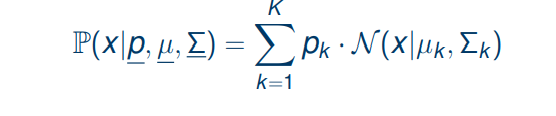

eq(2)

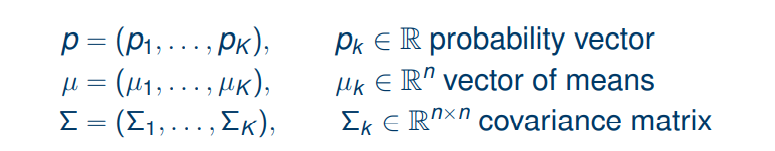

The distribution(gaussian from multivaruate) is defined as follows which is used in equation (1)

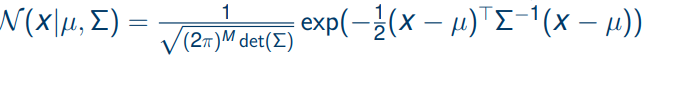


Just to illustrate, if we have 1-D data i.e, no. of feature is 1 and cluster(k=3), suppose looks like this.
Each cluster is defined by µ(mean), Σ(covariance), p(probability)

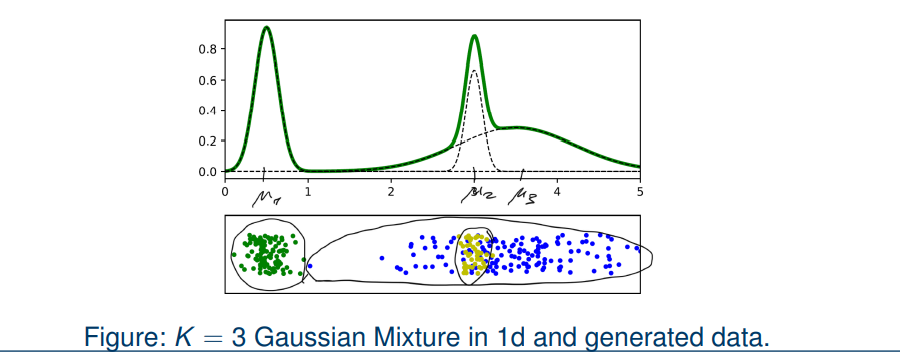

This is how the responsibilty of cluster k for x by observed relative frequencies, i.e., probability that
x is generated by Gaussian k.

eq(3)

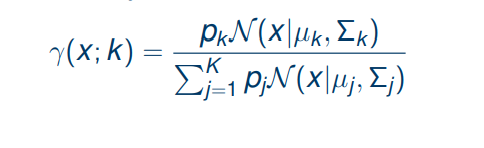

### <span style='font-weight:bold;color:#D13CC8'>M Step/Update Step:</span>

This is how the parameters should get updated.

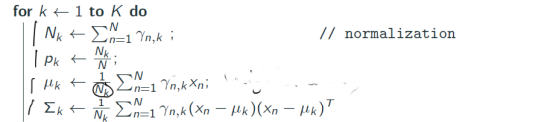

In [14]:
## Our aim is to work on m(centers) -> shape(no. of clusters, data dimension), Sigma(Covariance) -> shape(no. of clusters, data dimension), p(probability) -> shape(no. of clusters) of each cluster
## and the gamma(responsibility vector) -> shape(no. of data points, no. of clusters) which states the probability for
## each data point which belongs to each cluster.

def EM(data, K, n_iter = 25, return_all_iterations=False):
    
    """
    data -> data to input
    K -> no. of clusters
    n_iter = no. of iterations
    
    """
    
    
    N, M = data.shape # assume: N is number of data points, M is each data point's dimension

    sigma_def = 3
    
    ##-------------------------------------
    ## 1.  random initialization of cluster centers 
    ## Each cluster will have dimension as of dimension of our data like for 2-D data, 
    ## for ciluster 1 (x1,x2) for 3-D data (x1,x2,x3) for cluster 2 (x1', x2'), (x1',x2',x3') etc..
    m = np.zeros((K,M))
    for mm in range(M):
        m[:, mm] = np.random.uniform(np.min(data[:,mm]), np.max(data[:,mm]), (K, ))

    ##------------------------------
    ## 2.  Covariance of each cluster.
    Sigma = [sigma_def*np.eye(M) for kk in range(K)]

    ##--------------------------------------
    ## 3. responsbility vector for each data point with each cluster.
    gamma = 1/K*np.ones((N,K), dtype=np.int32)
    
    ##---------------------------------------
    ## 4. Prior probability for each cluster
    p = 1/K*np.ones((K,))
    gamma_old = None

    
    # if we want to get back all parameters for each single iteration
    if return_all_iterations:
        Sigma_history = [[np.copy(Sigma[k]) for k in range(K)]]
        m_history = np.zeros((1, K, M))
        m_history[0, :, :] = m
        gamma_history = np.zeros((1, N, K))
        gamma_history[0, :, :] = gamma
        p_history = np.zeros((1,K))
        p_history[0, :] = p
    # if we are only interested in the final clustering result
    else:
        m_history = None
        Sigma_history = None
        gamma_history = None
        p_history = None
    
    
    for it in range(n_iter):
        
        ###---------------------------------------- assignment step / E step ---------------------------------------###
        #------------------------------------------------------------------------------------------------------------#
        
        for n in range(N):
            x = data[n,:]

            terms = [p[k]* gaussian_formula(data[n], m[k,:], Sigma[k]) for k in range(K)]
            ## For each data point there will be gamma(responsbility) vector of shape of  of data
            gamma[n, :] = terms/np.sum(terms)

        
        if return_all_iterations:
            gamma_history = np.append(gamma_history, [gamma], 0)
        
        ###---------------------------------------- update step / M-step ---------------------------------------###
        #------------------------------------------------------------------------------------------------------------#
        Nk = [np.sum(gamma[:, k]) for k in range(K)] ## Summing all data point responsbilities for each cluster here we have 2 clusters.
        
        ## 1. Probaility update
        p = np.array(Nk)/N
        
        ## 2. Mean update
        means = np.dot(gamma.T, data) ## It will be of shape (K, M) k: no. of clusters center, M: Dimension of data 
        m_new = np.array([ means[k, :]/Nk[k] for k in range(K)]) ## Final calculate cluster centers

        
        # if we haven't moved a lot, break the loop and stick with current clustering
        if np.sum(np.sum((m-m_new)*(m-m_new))) < 10**-8:
            print("breaking!!")
            break
        
        ## 2. Mean update
        # else set means and continue
        m = m_new
        
        ## 3. Sigma update
        Sigma_new = [np.zeros((M, M)) for k in range(K)] # compute Sigma_new (new cluster covariances)
        for k in range(K):
            Sigmak = np.zeros((M,M))
            for n in range(N):
                x = data[n, :]
                Sigmak += gamma[n, k] * np.dot((x-m[k,:]).reshape((-1,1)), (x-m[k,:]).reshape((1,-1))) ## Calculating the sum of covariannces of each data point for that cluster
            Sigma_new[k] = Sigmak/Nk[k] ## Diving by each cluster responsbility sum

        Sigma = [np.copy(Sigma_new[k]) for k in range(K)]


                
        if return_all_iterations:
            m_history = np.append(m_history, [m], 0)
            Sigma_history.append([np.copy(Sigma_new[k]) for k in range(K)])
            p_history = np.append(p_history, [p], 0)
        
        
    return {"success": True, "m": m, "Sigma": Sigma, "p": p, "gamma": gamma, "m_history": m_history, "Sigma_history": Sigma_history, "p_history": p_history, "gamma_history": gamma_history} # return a dictionary 


In [11]:
n_iter = 100
K = 2 

df = pd.read_csv("/kaggle/input/data-test/faithful.csv")
data = df.loc[:,["eruptions", "waiting"]].to_numpy() 

In [12]:
df

,Unnamed: 0,eruptions,waiting
0,1,3.600,79
1,2,1.800,54
2,3,3.333,74
3,4,2.283,62
4,5,4.533,85
...,...,...,...
267,268,4.117,81
268,269,2.150,46
269,270,4.417,90
270,271,1.817,46


breaking!!


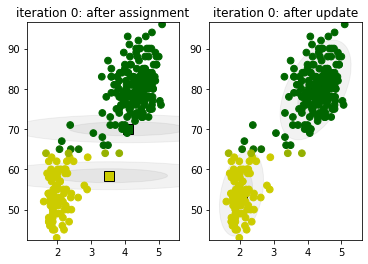

<Figure size 432x288 with 0 Axes>

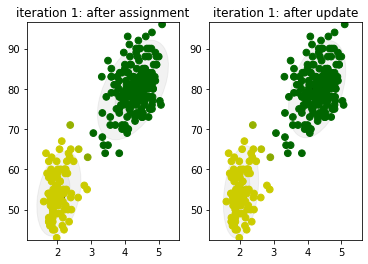

<Figure size 432x288 with 0 Axes>

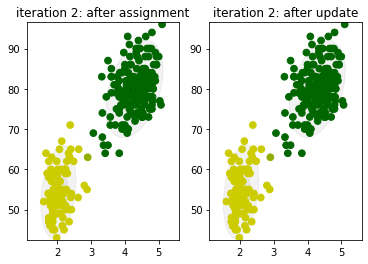

<Figure size 432x288 with 0 Axes>

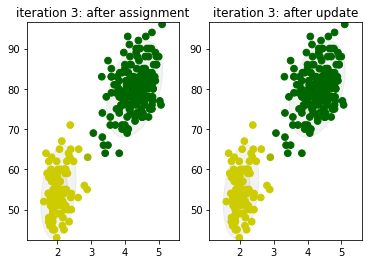

<Figure size 432x288 with 0 Axes>

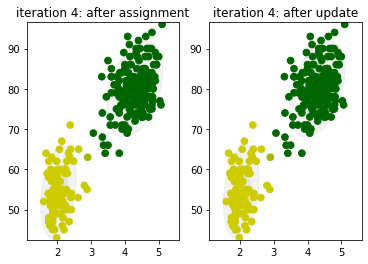

<Figure size 432x288 with 0 Axes>

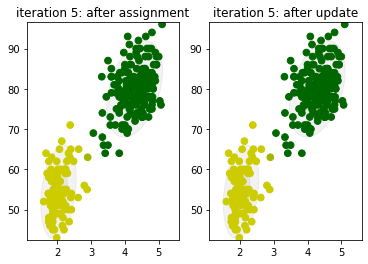

<Figure size 432x288 with 0 Axes>

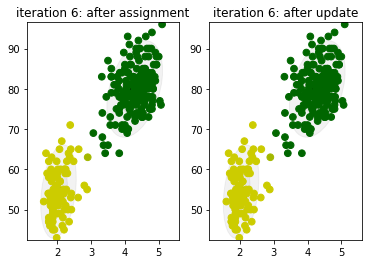

<Figure size 432x288 with 0 Axes>

In [13]:
xmin = np.min(data[:, 0])
xmax = np.max(data[:, 0])
ymin = np.min(data[:, 1])
ymax = np.max(data[:, 1])
dmin = min(xmin, ymin)
dmax = max(xmax, ymax)

N, M = data.shape


## Calling the EM Algorithm
ret = EM(data, K, n_iter = n_iter, return_all_iterations=True)

m = ret["m"]
m_history = ret["m_history"]

n_iter = m_history.shape[0] - 1

Sigma = ret["Sigma"]
Sigma_history = ret["Sigma_history"]
p = ret["p"]
p_history = ret["p_history"]
gamma = ret["gamma"]
gamma_history = ret["gamma_history"]

plt.ion()


## Function to draw plots, see how EM is performing clustering
def drawfig(it):
    plt.figure()
    ax1 = plt.subplot(1,2,1)
    ax2 = plt.subplot(1,2,2)
    ax1.set_xlim([xmin-0.5, xmax+0.5])
    ax1.set_ylim([ymin-0.5, ymax+0.5])
    m_now = m_history[it+1, :, :]
    m_old = m_history[it, :, :]

    gamma_now = gamma_history[it+1, :]
    Sigma_now = Sigma_history[it+1]
    Sigma_old = Sigma_history[it]


    for k in range(K):
        ax1.plot(m_old[k, 0], m_old[k, 1], color = colors[k], marker = "s", markeredgecolor="k", markersize=10)



    if K == 2: # linear interpolation between colors possible
        mixcoeffs = gamma_now[:, 1]
        sc = ax1.scatter(data[:, 0], data[:, 1], c=[colorFader(colors[0],colors[1],mixc) for mixc in mixcoeffs], s=45, zorder=2)

    else: # for more clusters we can only color with the dominant cluster :(
        cs_index = [int(list(gamma_now[n, :]).index(max(gamma_now[n, :]))) for n in range(N)]
        ax1.scatter(data[:, 0], data[:, 1], c=[colors[csi] for csi in cs_index], s=45, zorder=2)

    for k in range(K):
        plot_ellipse(m_old[k, :], Sigma_old[k], ax1)
        plot_ellipse(m_old[k, :], Sigma_old[k], ax1, n_std=2.0)




    ax2.set_xlim([xmin-0.5, xmax+0.5])
    ax2.set_ylim([ymin-0.5, ymax+0.5])

    for k in range(K):
        ax2.plot(m_now[k, 0], m_now[k, 1], color = colors[k], marker = "s", markeredgecolor="k", markersize=10)




    if K == 2: # linear interpolation between colors possible
        mixcoeffs = gamma_now[:, 1]
        sc = ax2.scatter(data[:, 0], data[:, 1], c=[colorFader(colors[0],colors[1],mixc) for mixc in mixcoeffs], s=45, zorder=2)

    else: # for more clusters we can only color with the dominant cluster :(
        cs_index = [int(list(gamma_now[n, :]).index(max(gamma_now[n, :]))) for n in range(N)]
        ax2.scatter(data[:, 0], data[:, 1], c=[colors[csi] for csi in cs_index], s=45, zorder=2)
    for k in range(K):
        plot_ellipse(m_now[k, :], Sigma_now[k], ax2)
        plot_ellipse(m_now[k, :], Sigma_now[k], ax2, n_std=2.0)

    ax1.set_title("iteration " + str(it) + ": after assignment")
    ax2.set_title("iteration " + str(it) + ": after update")
    plt.plot()
    plt.show()
    plt.savefig(f"figure_{it}.png")

for i in range(m_history.shape[0]-1):
    drawfig(i)

## <span style='font-weight:bold;color:#D13CC8'>K-means Algorithm:</span>

## <span style='font-weight:bold;color:#D13CC8'>Step1:</span> Initialize the cluster centers.

## <span style='font-weight:bold;color:#D13CC8'>Step2:</span> Calculate the distance between each cluster center and the data point and assign the data point to cluster center which is nearer.

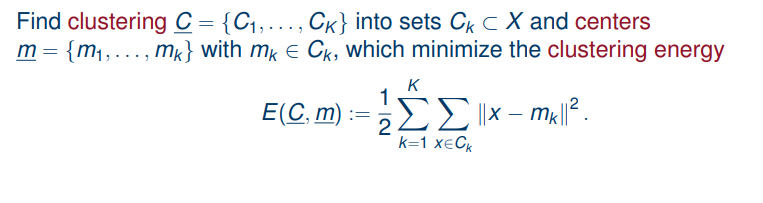

In [17]:
## Our aim is to work on m(centers) -> shape(no. of clusters, dimension of data) of cluster and assign labels to each data point which stores in a[].


def KMeans(data, K, return_all_iterations=False):
    
    N, M = data.shape # assume: N is number of data points, M is each data point's dimension
    
    ## random initialization of cluster centers.
    m = np.random.uniform(np.min(data), np.max(data), (K, M))
    ## Zero initialization for the assignment of each data point.
    a = np.zeros((N,), dtype=np.int32)
    a_old = None
    
    if return_all_iterations:
        a_history = np.zeros((1, N), dtype=np.int32)
        a_history[0, :] = a
        m_history = np.zeros((1, K, M))
        m_history[0, :] = m
    else:
        a_history = None
        m_history = None
    
    it = 1
    while True:
        # assignment step
        for n in range(N):
            x = data[n, :]
            distances = [np.dot(x-m[k, :], x-m[k, :]) for k in range(K)]
            a[n] = int(distances.index(min(distances)))
        
        # if assignment did not change anything, break loop and return value afterwards
        if a_old is not None and np.dot(a-a_old, a-a_old) < 1e-10:
            break
            
        if return_all_iterations:
            a_history = np.append(a_history, [a], 0)
        

        # update step
        
        means = np.zeros((K, M))
        numelems = np.zeros((K, ))
        for n in range(N):
            means[a[n], :] += data[n, :]
            numelems[a[n]] += 1
            
        for k in range(K):
            if numelems[k] == 0:
                continue
            m[k, :] = means[k, :]/numelems[k]
        
        if return_all_iterations:
            m_history = np.append(m_history, [m], 0)
        
        # copy values of a into a_old. Use this if you need to copy numpy arrays, 
        # instead of just setting a_old = a (side effects possible because this creates a reference)
        a_old = np.copy(a)
        
        it += 1
        
    return {"m": m, "a": a, "m_history": m_history, "a_history": a_history} # return a dictionary 


In [18]:
K = 3 # number of clusters
show_iterations = True

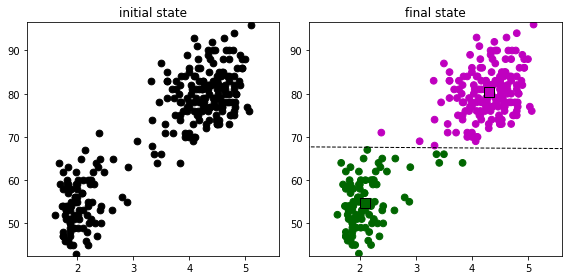

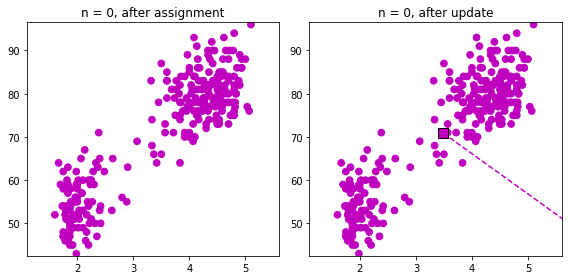

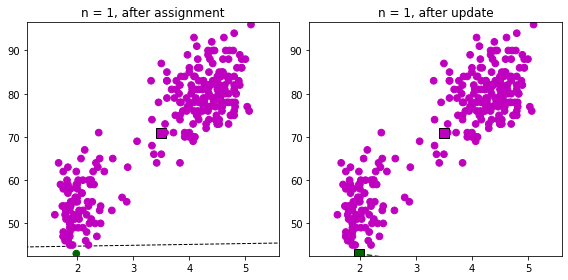

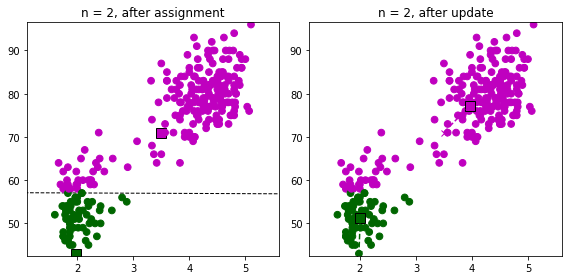

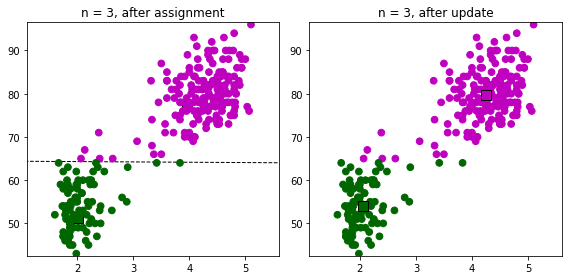

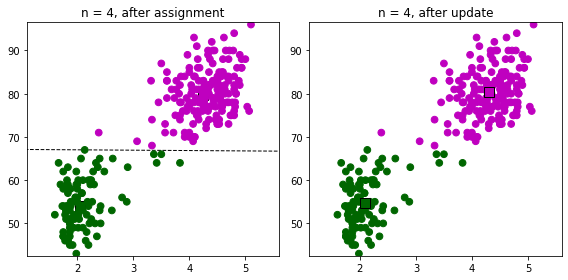

In [19]:
xmin = np.min(data[:, 0])
xmax = np.max(data[:, 0])
ymin = np.min(data[:, 1])
ymax = np.max(data[:, 1])


N, M = data.shape

ret = KMeans(data, K, return_all_iterations=show_iterations)
m = ret["m"]
m_history = ret["m_history"]
a = ret["a"]
a_history = ret["a_history"]


if M == 2:
    if m_history is not None:
        num_its = m_history.shape[0]
        fig = plt.figure(figsize=(8,4));   
        ax1 = plt.subplot(1,2,1)
        plt.xlim([xmin-0.5, xmax+0.5])
        plt.ylim([ymin-0.5, ymax+0.5])

        for k in range(K):
            plt.plot(m_history[0, k, 0], m_history[0, k, 1], color = colors[k], marker = "s", markeredgecolor="k", markersize=10)

        plt.scatter(data[:, 0], data[:, 1], color="k", s=45)
        #plt.axis("equal")
        #plt.title("n = " + str(it) + ", after update")
        plt.title("initial state")
        plt.tight_layout()
        ax2 = plt.subplot(1,2,2)
        if K >= 3:
            vor = Voronoi(m)
            voronoi_plot_2d(vor, show_vertices=False, ax=ax2)
        plt.xlim([xmin-0.5, xmax+0.5])
        plt.ylim([ymin-0.5, ymax+0.5])

        for k in range(K):
            plt.plot(m_history[-1, k, 0], m_history[-1, k, 1], color = colors[k], marker = "s", markeredgecolor="k", markersize=10)



        # compute and plot separator line (for K = 2)
        if K == 2:
            v = m[1, :] - m[0, :]
            a0 = np.dot(v, m[0, :])
            a1 = np.dot(v, m[1, :])
            slope = -v[0]/v[1]
            intercept = (m[0, 1] + m[1, 1])/2 - slope*(m[0, 0] + m[1, 0])/2
            sep = lambda x: slope*x + intercept
            plt.plot([xmin, xmax], [sep(xmin), sep(xmax)], '--')

        plt.scatter(data[:, 0], data[:, 1], color=[colors[aa] for aa in a], s=45)
        #plt.axis("equal")
        plt.xlim([xmin-0.5, xmax+0.5])
        plt.ylim([ymin-0.5, ymax+0.5])
        plt.title("final state")
        plt.tight_layout()
        # full visualization of all iterations
        for it in range(num_its-1):
            m_now = m_history[it+1, :, :]
            m_old = m_history[it, :, :]

            a_now = a_history[it+1, :]

            plt.figure(figsize=(8,4));
            plt.ion()
            ax1 = plt.subplot(1,2,1)
            if K >= 3:
                vor = Voronoi(m_old)
                voronoi_plot_2d(vor, show_vertices=False, ax=ax1)
            plt.xlim([xmin-0.5, xmax+0.5])
            plt.ylim([ymin-0.5, ymax+0.5])
            for k in range(K):
                plt.plot(m_old[k, 0], m_old[k, 1], color = colors[k], marker = "s", markeredgecolor="k", markersize=10)

            # compute and plot separator line (for K = 2)
            if K == 2:
                v = m_old[1, :] - m_old[0, :]
                a0 = np.dot(v, m_old[0, :])
                a1 = np.dot(v, m_old[1, :])
                slope = -v[0]/v[1]
                intercept = (m_old[0, 1] + m_old[1, 1])/2 - slope*(m_old[0, 0] + m_old[1, 0])/2
                sep = lambda x: slope*x + intercept
                plt.plot([xmin, xmax], [sep(xmin), sep(xmax)], '--')

            plt.scatter(data[:, 0], data[:, 1], c=[colors[aa] for aa in a_now], s=45, zorder=2)
            plt.title("n = " + str(it) + ", after assignment")


            ax2 = plt.subplot(1,2,2)
            plt.xlim([xmin-0.5, xmax+0.5])
            plt.ylim([ymin-0.5, ymax+0.5])

            for k in range(K):
                plt.plot(m_old[k, 0], m_old[k, 1], color = colors[k], marker = "x")
                plt.plot(m_now[k, 0], m_now[k, 1], color = colors[k], marker = "s", markeredgecolor="k", markersize=10)
                plt.plot([m_now[k, 0], m_old[k, 0]], [m_now[k, 1], m_old[k, 1]], color = colors[k], linestyle = "--") 

            plt.scatter(data[:, 0], data[:, 1], color=[colors[aa] for aa in a_now], s=45)
            plt.title("n = " + str(it) + ", after update")
            plt.tight_layout()
            plt.show()

    else:
        fig = plt.figure()
        plt.ion()
        plt.xlim([xmin-0.5, xmax+0.5])
        plt.ylim([ymin-0.5, ymax+0.5])
        if K >= 3:
            vor = Voronoi(m)
            voronoi_plot_2d(vor, show_vertices=False, ax=fig.gca())
        for k in range(K):
            plt.plot(m[k, 0], m[k, 1], color = colors[k], marker = "s", markeredgecolor="k", markersize=10)

        # compute and plot separator line (for K = 2)
        if K == 2:
            v = m[1, :] - m[0, :]
            a0 = np.dot(v, m[0, :])
            a1 = np.dot(v, m[1, :])
            slope = -v[0]/v[1]
            intercept = (m[0, 1] + m[1, 1])/2 - slope*(m[0, 0] + m[1, 0])/2
            sep = lambda x: slope*x + intercept
            plt.plot([xmin, xmax], [sep(xmin), sep(xmax)], '--')

        plt.scatter(data[:, 0], data[:, 1], color=[colors[aa] for aa in a], s=45)
        #plt.axis("equal")
        plt.xlim([xmin-0.5, xmax+0.5])
        plt.ylim([ymin-0.5, ymax+0.5])

        plt.show()
else: 
    print("Visualization only in 2d")